In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib, os

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay,
    precision_recall_curve, PrecisionRecallDisplay,
    roc_curve, f1_score, precision_score, recall_score
)

sns.set_theme(style="whitegrid")
os.makedirs("../reports", exist_ok=True)
print("Imports ready.")

Imports ready.


In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv").values
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
X_test  = pd.read_csv("../data/processed/X_test.csv").values
y_test  = pd.read_csv("../data/processed/y_test.csv").values.ravel()

# Retrain rf-large — our champion config from Phase 5
champion = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)
champion.fit(X_train, y_train)

# Get both class predictions and fraud probabilities
y_pred  = champion.predict(X_test)
y_proba = champion.predict_proba(X_test)[:, 1]

print("Champion model ready.")
print(f"\nDefault threshold (0.5) results:")
print(classification_report(y_test, y_pred,
                             target_names=["Legitimate", "Fraud"]))

Champion model ready.

Default threshold (0.5) results:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.65      0.85      0.74        98

    accuracy                           1.00     56962
   macro avg       0.83      0.92      0.87     56962
weighted avg       1.00      1.00      1.00     56962



Confusion Matrix Breakdown:
  True Negatives  (correctly said legitimate): 56,820
  False Positives (wrongly flagged as fraud):  44
  False Negatives (missed fraud — DANGEROUS):  15
  True Positives  (correctly caught fraud):    83

  Fraud caught:  83/98 (84.7%)
  Fraud missed:  15/98 (15.3%)
  False alarms:  44 legitimate transactions wrongly flagged


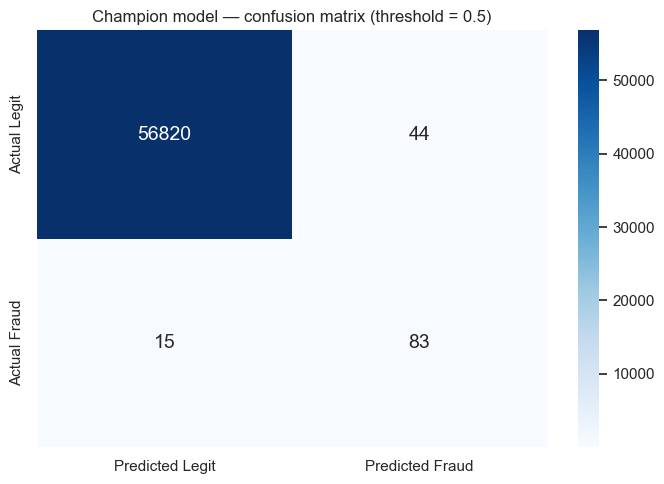

In [3]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix Breakdown:")
print(f"  True Negatives  (correctly said legitimate): {tn:,}")
print(f"  False Positives (wrongly flagged as fraud):  {fp:,}")
print(f"  False Negatives (missed fraud — DANGEROUS):  {fn:,}")
print(f"  True Positives  (correctly caught fraud):    {tp:,}")
print(f"\n  Fraud caught:  {tp}/{tp+fn} ({tp/(tp+fn)*100:.1f}%)")
print(f"  Fraud missed:  {fn}/{tp+fn} ({fn/(tp+fn)*100:.1f}%)")
print(f"  False alarms:  {fp:,} legitimate transactions wrongly flagged")

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Predicted Legit", "Predicted Fraud"],
            yticklabels=["Actual Legit", "Actual Fraud"],
            annot_kws={"size": 14})
ax.set_title("Champion model — confusion matrix (threshold = 0.5)")
plt.tight_layout()
plt.savefig("../reports/champion_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

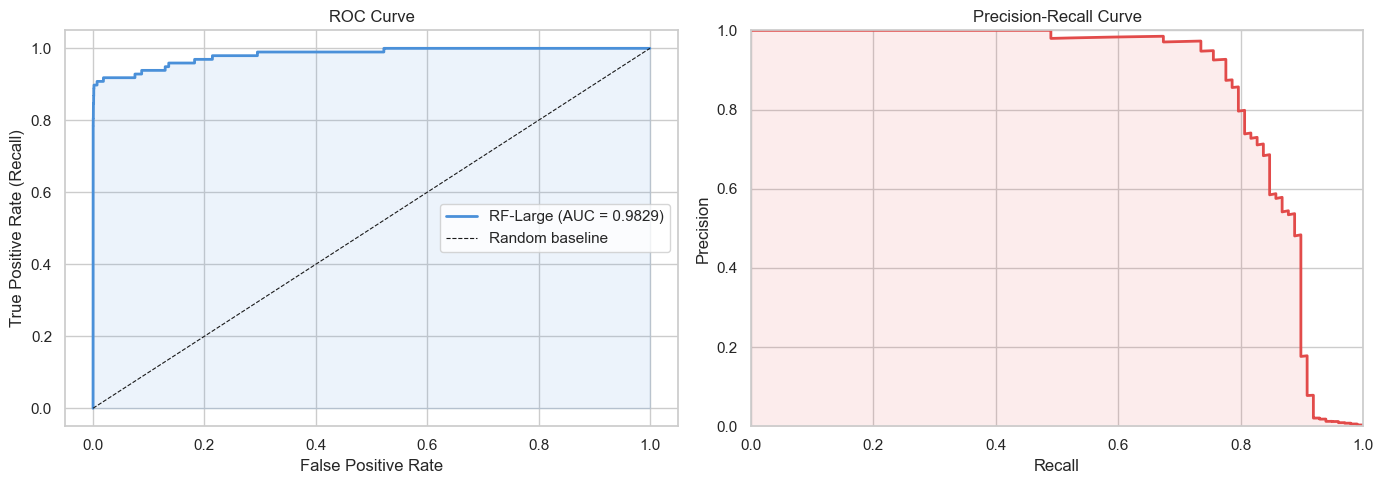

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

axes[0].plot(fpr, tpr, color="#4A90D9", linewidth=2,
             label=f"RF-Large (AUC = {auc_score:.4f})")
axes[0].plot([0,1],[0,1], "k--", linewidth=0.8, label="Random baseline")
axes[0].fill_between(fpr, tpr, alpha=0.1, color="#4A90D9")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].set_title("ROC Curve")
axes[0].legend()

# Precision-Recall Curve
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_proba)

axes[1].plot(recall_vals, precision_vals, color="#E24B4A", linewidth=2)
axes[1].fill_between(recall_vals, precision_vals, alpha=0.1, color="#E24B4A")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig("../reports/roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

Default threshold (0.50):
  Precision: 0.6535
  Recall:    0.8469
  F1:        0.7378

Optimal threshold (0.8454):
  Precision: 0.9268
  Recall:    0.7755
  F1:        0.8444


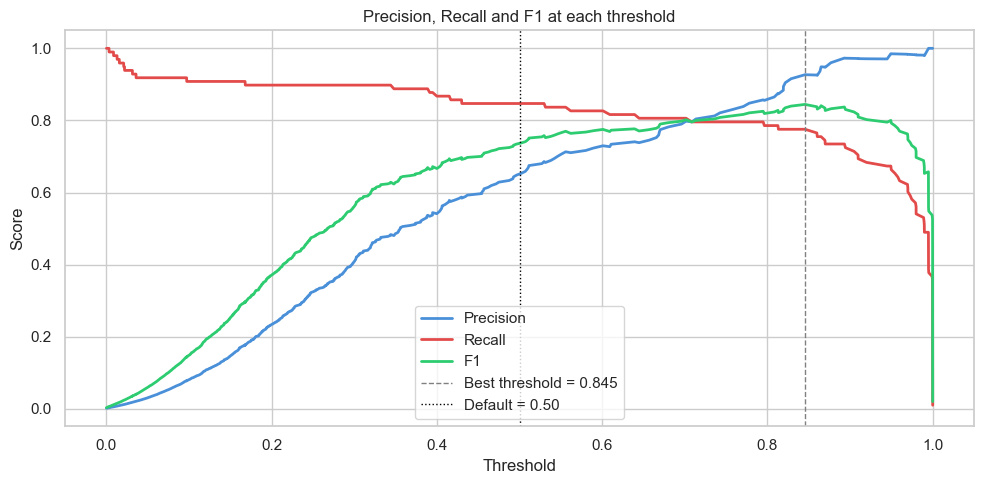

In [5]:
# Calculate precision, recall and F1 at every possible threshold
thresholds     = pr_thresholds  # thresholds from precision_recall_curve
precision_at_t = precision_vals[:-1]
recall_at_t    = recall_vals[:-1]

# F1 score at each threshold — harmonic mean of precision and recall
f1_at_t = 2 * (precision_at_t * recall_at_t) / (precision_at_t + recall_at_t + 1e-8)

# Find threshold that maximises F1
best_idx       = np.argmax(f1_at_t)
best_threshold = thresholds[best_idx]
best_f1        = f1_at_t[best_idx]

print(f"Default threshold (0.50):")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred):.4f}")
print(f"\nOptimal threshold ({best_threshold:.4f}):")
y_pred_tuned = (y_proba >= best_threshold).astype(int)
print(f"  Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_tuned):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred_tuned):.4f}")

# Plot how precision and recall change as we move the threshold
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precision_at_t, label="Precision", color="#4A90D9", linewidth=2)
plt.plot(thresholds, recall_at_t,    label="Recall",    color="#E24B4A", linewidth=2)
plt.plot(thresholds, f1_at_t,        label="F1",        color="#2ECC71", linewidth=2)
plt.axvline(best_threshold, color="gray", linestyle="--", linewidth=1,
            label=f"Best threshold = {best_threshold:.3f}")
plt.axvline(0.5, color="black", linestyle=":", linewidth=1, label="Default = 0.50")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 at each threshold")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

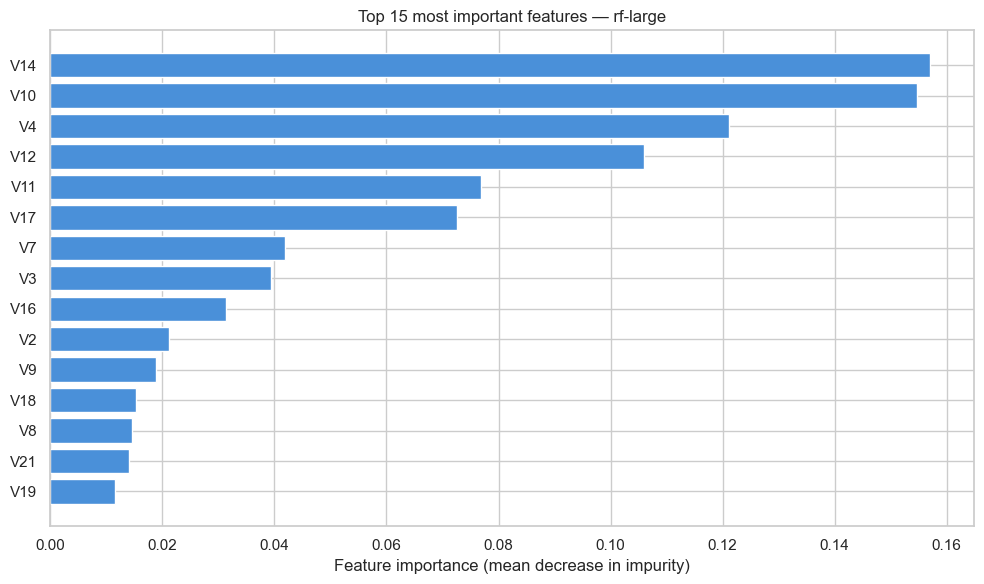

Top 5 most important features:
feature  importance
    V14    0.157044
    V10    0.154670
     V4    0.121082
    V12    0.105889
    V11    0.076794


In [6]:
# Random Forest tracks how much each feature reduces impurity — that's importance
feature_names  = pd.read_csv("../data/processed/X_test.csv").columns.tolist()
importances    = champion.feature_importances_
importance_df  = pd.DataFrame({
    "feature":    feature_names,
    "importance": importances
}).sort_values("importance", ascending=True).tail(15)

plt.figure(figsize=(10, 6))
bars = plt.barh(importance_df["feature"], importance_df["importance"],
                color="#4A90D9", edgecolor="white")
plt.xlabel("Feature importance (mean decrease in impurity)")
plt.title("Top 15 most important features — rf-large")
plt.tight_layout()
plt.savefig("../reports/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 most important features:")
print(importance_df.tail(5)[["feature","importance"]].iloc[::-1].to_string(index=False))

In [7]:
import json

# Save the champion model
os.makedirs("../models", exist_ok=True)
joblib.dump(champion, "../models/champion_rf.joblib")

# Save the optimal threshold alongside it — our API will need this
config = {
    "model":     "rf-large",
    "threshold": float(best_threshold),
    "roc_auc":   float(auc_score),
    "n_estimators": 200,
    "max_depth": 15
}
with open("../models/champion_config.json", "w") as f:
    json.dump(config, f, indent=2)

print(f"Saved champion model and config.")
print(f"Config: {config}")

Saved champion model and config.
Config: {'model': 'rf-large', 'threshold': 0.8454173890894922, 'roc_auc': 0.9828746425413158, 'n_estimators': 200, 'max_depth': 15}
